In [39]:
import os
import re
import math
import shutil
import subprocess

from datetime import datetime, timedelta, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("QtAgg")
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from matplotlib.dates import DateFormatter
from dateutil.tz import tzutc, tzlocal
from scipy import stats
from scipy.optimize import brentq, curve_fit, fsolve


import sys
import signal
import tempfile
import time
from collections import Counter
from IPython.display import clear_output

from scipy.interpolate import PchipInterpolator
from scipy.interpolate import UnivariateSpline

In [67]:
#load GSSHA run functions and post processing

%load_ext autoreload
%autoreload 2

import GSSHA_set_and_run_functions as gf
import GSSHA_post_process_functions as gppf

In [68]:
#load the GDAL functions for GIS post processing

#path to script
cwd = os.getcwd() ; script_dir = Path.cwd() 

GSSHA_executables = script_dir / 'GSSHA_applications'

#Path to the gdal environment
gdal_python = Path(
    r"C:\Users\bgorberg\anaconda3\envs\gdal_env\python.exe"
)

run_gdal_script = script_dir / "run_GDAL.py"

# Set up file paths for inputs

In [81]:
GSSHA_prj_name = "Waialua_FIM_testing"
Gauge_Datum_offset = 13.835


model_dir = script_dir / GSSHA_prj_name

final_stage_model_results_dir = model_dir / ("FINAL_STAGE_MAPS_WITH_OFFSET_" + str(Gauge_Datum_offset))


final_map_results_folder = "Waialua_flood_stage_results"
final_map_results_folder_dir = script_dir / final_map_results_folder
final_map_results_folder_dir.mkdir(parents=True, exist_ok=True)

# Read results : input flow, model water surface elevation, and modeled gauge discharge

In [87]:
modeling_results = gppf.read_WSE_and_discharge_from_model_results(model_results_folder_directory = final_stage_model_results_dir, Gauge_Datum_offset = Gauge_Datum_offset)
modeling_results

,WSE_m,gauge_discharge_cms,gfl_filename,modeled_gauge_reading
input_flow_cms,,,,
113.83,4.803368,146.0,Waialua_FIM_testing_26.0_OUTPUT-maxflood-dep-m...,29.594083
141.59,4.022367,142.0,Waialua_FIM_testing_27.0_OUTPUT-maxflood-dep-m...,27.031742
177.21,4.324673,178.0,Waialua_FIM_testing_28.0_OUTPUT-maxflood-dep-m...,28.023561
228.31,4.647343,226.0,Waialua_FIM_testing_29.0_OUTPUT-maxflood-dep-m...,29.082188
318.08,4.908221,306.0,Waialua_FIM_testing_30.0_OUTPUT-maxflood-dep-m...,29.938087
419.98,5.239696,369.0,Waialua_FIM_testing_31.0_OUTPUT-maxflood-dep-m...,31.025605
562.25,5.558266,412.0,Waialua_FIM_testing_32.0_OUTPUT-maxflood-dep-m...,32.070781
1229.45,6.153028,462.0,Waialua_FIM_testing_34.0_OUTPUT-maxflood-dep-m...,34.022101
1834.18,6.468183,483.0,Waialua_FIM_testing_35.0_OUTPUT-maxflood-dep-m...,35.056075


# Read flood stage map output and create tif files stored in a folder for GIS analysis

In [98]:
gfl_files = sorted([f for f in os.listdir(final_stage_model_results_dir ) if f.lower().endswith(".gfl")])


for FIM_gfl in gfl_files:

    gf.copy_text_file(
        folder_path=final_stage_model_results_dir,
        original_filename=FIM_gfl,
        output_folder=final_map_results_folder_dir,
        new_filename=FIM_gfl,
    )
    
    #convert GSSHA gfl output to ascii
    ascii_path = gppf.convert_gfl_ASCII(
        gfl_path=final_map_results_folder_dir  / FIM_gfl,
        ascii_header_path=model_dir / (GSSHA_prj_name + ".ele"),
        out_ascii_path= final_map_results_folder_dir  / (FIM_gfl.split(".gfl")[0] + ".asc")
    )
    
    #add ascii projection
    prj = subprocess.run(
        [
            str(gdal_python),
            str(run_gdal_script),
            "define_projection_ASCII",
            str(ascii_path),
        ],
        capture_output=True,
        text=True,
    )

    # convert ASCII to GeoTIFF
    tif = subprocess.run(
        [
            str(gdal_python),
            str(run_gdal_script),
            "convert_ASCII_to_GeoTIFF",
            str(ascii_path),
        ],
        capture_output=True,
        text=True,
    )


In [95]:
ascii_path

WindowsPath('C:/Users/bgorberg/Documents/GitHub/Flood_Stage_Maps/RUN_GSSHA/Waialua_flood_stage_results/Waialua_FIM_testing_36.0_OUTPUT-maxflood-dep-m-86841.asc')

# Calculate the flood stage for each return period

Using PeakFq drop in the file that saves all the gauge discharge flow values for each return period and then read that

In [76]:
gauge_discharge_WSE = dict(
    zip(
        modeling_results["gauge_discharge_cms"],
        modeling_results["WSE_m"],
    )
)

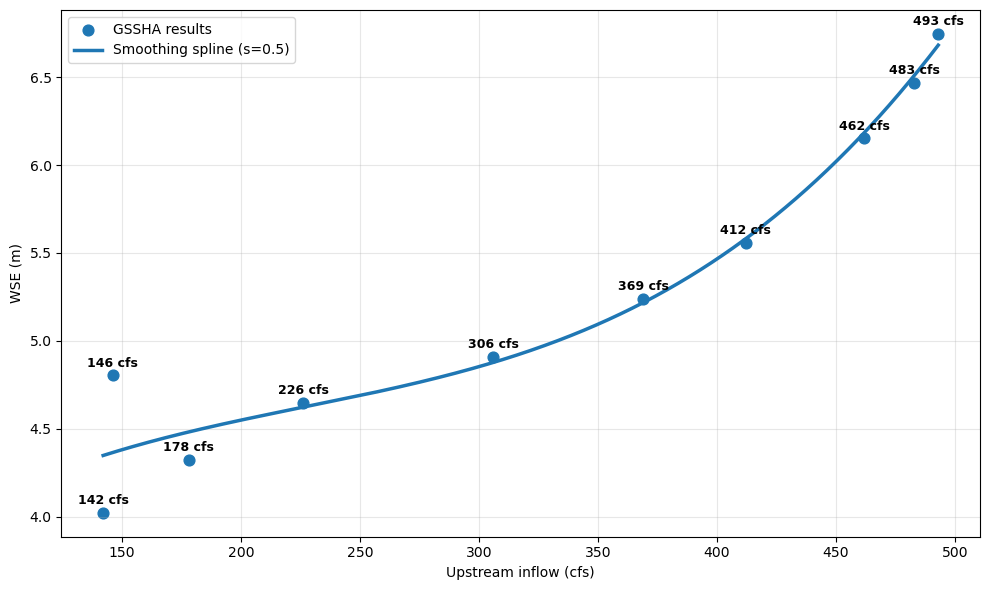

In [80]:
%matplotlib inline
interpolation_variables = gppf.low_flow_interpolation(
    gauge_discharge_WSE,
    smoothing=0.5,
    plot=True,
)